# Sales Prediction using Python

CodeAlpha Data Science Internship, Task 4.

A regression model predicting sales from advertising spend across three
channels, with an examination of which channels the spend actually moves.

**Objectives**

- Load and inspect the raw data before modifying it
- Clean it and record what was found
- Explore how sales relates to spend in each channel
- Train a regression model and evaluate it on unseen data
- Establish which channels carry the prediction and what that implies for
  advertising decisions

**Data source**

`Advertising.csv`, supplied by CodeAlpha. Spend on television, radio and
newspaper advertising against the resulting sales. Units are not stated in the
file. [Row count filled in after inspection.]

**Author**

Ahmed Yunus Albarka

In [7]:
# Import necessary libraries

# numpy is used for the numeric operations pandas relies on
import numpy as np

# pandas handles the data table itself
import pandas as pd

# matplotlib is the base plotting library
import matplotlib.pyplot as plt

# seaborn sits on top of matplotlib and gives cleaner statistical charts
import seaborn as sns

# Show every column when printing a DataFrame rather than hiding some
pd.set_option("display.max_columns", None)

# Print floats to two decimal places
pd.set_option("display.float_format", "{:.2f}".format)

# One consistent look for every chart in the notebook
sns.set_theme(style="whitegrid")

# Default chart size, so it does not need repeating on each plot
plt.rcParams["figure.figsize"] = (10, 5)

In [8]:
# Import os so we can see what is actually on disk
import os

# The folder where the dataset should be sitting
folder = r"C:\Users\talk2\GitHub\CodeAlpha_SalesPrediction\Data"

# Check the folder exists before trying to list it
if os.path.exists(folder):
    # Print every file inside, so we use the real filename rather than a guess
    print(os.listdir(folder))
else:
    # If this prints, the folder was not created or the path is wrong
    print("Folder not found:", folder)

['Advertising.csv']


In [9]:
# pandas handles the data table
import pandas as pd

# Read the file using the real filename from the listing
df = pd.read_csv(r"C:\Users\talk2\GitHub\CodeAlpha_SalesPrediction\Data\Advertising.csv")

# Rows and columns
print(df.shape)

# Column names and types, to see what is numeric and whether a date exists
print(df.dtypes)

# First rows to see actual values
df.head()

(200, 5)
Unnamed: 0      int64
TV            float64
Radio         float64
Newspaper     float64
Sales         float64
dtype: object


,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.10,37.80,69.20,22.10
1,2,44.50,39.30,45.10,10.40
2,3,17.20,45.90,69.30,9.30
3,4,151.50,41.30,58.50,18.50
4,5,180.80,10.80,58.40,12.90


## 2. Inspect the raw data

Nothing is modified here. The purpose is to see what the file contains and what
needs fixing before deciding how to fix it.

`TV`, `Radio` and `Newspaper` are advertising spend in each channel. `Sales` is
the result and is the target. The file does not state its units.

Two things the task asks for are not in this data. It mentions target segment and
platform, and neither column exists here, so no analysis of either is possible.
It also offers time series models as an option, which requires a date or period
column. There is none, so every row is an independent observation with no order,
and this is treated as a regression problem throughout.

In [10]:
# Rows and columns as loaded
print("Shape on load:", df.shape)

# Missing values per column
print("\nMissing values per column:")
print(df.isna().sum())

# Rows that are exact copies of another row
print("Duplicate rows:", df.duplicated().sum())

# Check whether Unnamed: 0 is just a row counter. If it runs 1 to the row
# count with no repeats, it carries no information and can be dropped
print("\nUnnamed: 0 range:", df["Unnamed: 0"].min(), "to", df["Unnamed: 0"].max())
print("Unnamed: 0 unique values:", df["Unnamed: 0"].nunique())

# Summary statistics for every numeric column
df.describe()

Shape on load: (200, 5)

Missing values per column:
Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64
Duplicate rows: 0

Unnamed: 0 range: 1 to 200
Unnamed: 0 unique values: 200


,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.00,200.00,200.00,200.00,200.00
mean,100.50,147.04,23.26,30.55,14.02
std,57.88,85.85,14.85,21.78,5.22
min,1.00,0.70,0.00,0.30,1.60
25%,50.75,74.38,9.97,12.75,10.38
50%,100.50,149.75,22.90,25.75,12.90
75%,150.25,218.82,36.52,45.10,17.40
max,200.00,296.40,49.60,114.00,27.00


### What the inspection found

200 rows, 5 columns. No missing values and no duplicate rows, so no cleaning is
required beyond one column.

`Unnamed: 0` runs from 1 to 200 with 200 unique values across 200 rows. It is a
row counter left over from however the file was exported and carries no
information, so it is dropped.

The three spend columns sit on different scales. Television spend averages 147.04
and reaches 296.40. Radio averages 23.26 with a maximum of 49.60. Newspaper
averages 30.55 but reaches 114.00, more than twice its own 75th percentile of
45.10, so a small number of rows carry much heavier newspaper spend than the
rest.

Radio has a minimum of 0.00, so at least one campaign ran with no radio spend at
all. Television and newspaper both have minimums close to zero as well, at 0.70
and 0.30.

Sales range from 1.60 to 27.00 with a mean of 14.02 and a median of 12.90, so the
distribution leans slightly toward the lower end.

In [12]:
# Drop the leftover row counter. errors="ignore" means the cell can be run
# again without failing once the column has already been removed
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

# Confirm what remains
print("Shape after cleaning:", df.shape)
print("Columns:", list(df.columns))

Shape after cleaning: (200, 4)
Columns: ['TV', 'Radio', 'Newspaper', 'Sales']


In [13]:
# Correlation of each spend channel with sales. Values near 1 mean the two
# move together closely, values near 0 mean they move independently
print("Correlation with Sales:")
print(df.corr()["Sales"].sort_values(ascending=False))

Correlation with Sales:
Sales       1.00
TV          0.78
Radio       0.58
Newspaper   0.23
Name: Sales, dtype: float64


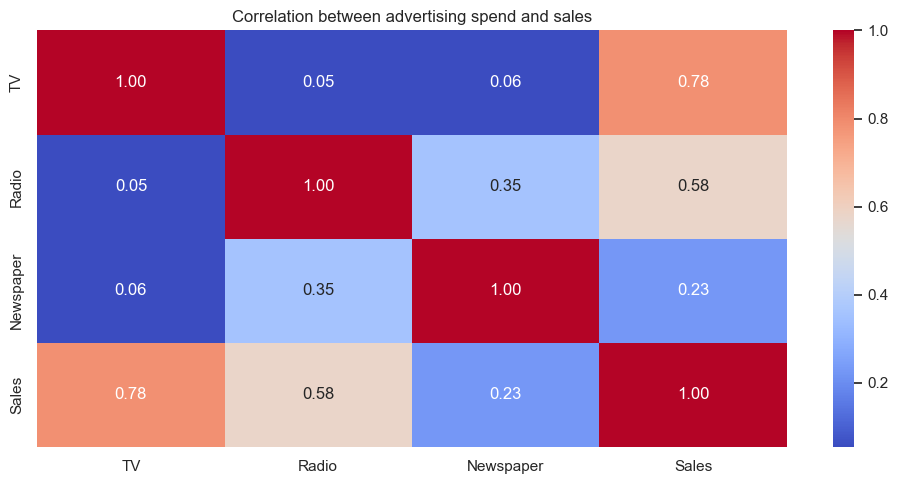

In [14]:
# Heatmap of every pair, so relationships between the channels themselves
# are visible as well as their relationship with sales
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation between advertising spend and sales")
plt.tight_layout()
plt.show()

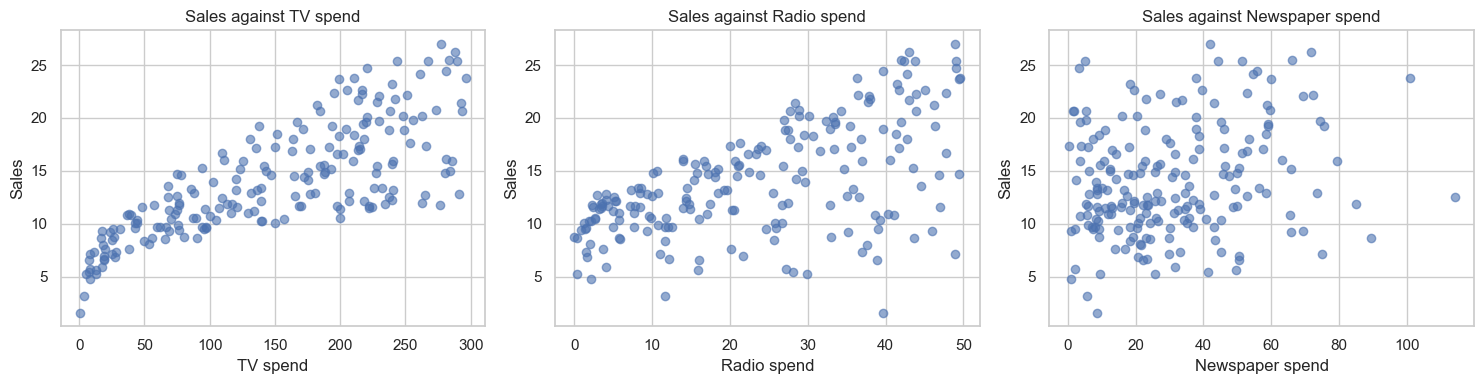

In [15]:
# Plot sales against each channel separately. The shape of each scatter shows
# whether the relationship is a straight line or something else
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, channel in zip(axes, ["TV", "Radio", "Newspaper"]):
    ax.scatter(df[channel], df["Sales"], alpha=0.6)
    ax.set_xlabel(f"{channel} spend")
    ax.set_ylabel("Sales")
    ax.set_title(f"Sales against {channel} spend")

plt.tight_layout()
plt.show()

In [16]:
# Split the data at the median radio spend, then check whether newspaper
# still relates to sales within each half. If the 0.23 correlation was
# borrowed from radio, it should weaken or disappear inside each group
median_radio = df["Radio"].median()

# Campaigns with below-median radio spend
low_radio = df[df["Radio"] <= median_radio]

# Campaigns with above-median radio spend
high_radio = df[df["Radio"] > median_radio]

print("Newspaper against Sales, all rows:", round(df["Newspaper"].corr(df["Sales"]), 3))
print("Within low radio spend:", round(low_radio["Newspaper"].corr(low_radio["Sales"]), 3), f"({len(low_radio)} rows)")
print("Within high radio spend:", round(high_radio["Newspaper"].corr(high_radio["Sales"]), 3), f"({len(high_radio)} rows)")

Newspaper against Sales, all rows: 0.228
Within low radio spend: 0.056 (100 rows)
Within high radio spend: 0.111 (100 rows)


In [19]:
# Group TV spend into four bands and show mean sales in each.
# If returns diminish, the jump between bands shrinks as spend rises
df["TV_band"] = pd.qcut(df["TV"], 4)

print("Mean sales by TV spend band:")
print(df.groupby("TV_band", observed=True)["Sales"].agg(["mean", "count"]).round(2))

Mean sales by TV spend band:
                   mean  count
TV_band                       
(0.699, 74.375]    8.39     50
(74.375, 149.75]  12.69     50
(149.75, 218.825] 16.55     50
(218.825, 296.4]  18.47     50


### What the exploration found

Television correlates with sales at 0.78, radio at 0.58 and newspaper at 0.23.

The newspaper figure does not survive checking. Newspaper spend correlates with
radio spend at 0.35, so campaigns that buy newspaper also tend to buy radio.
Splitting the data at the median radio spend and recomputing within each half
drops the newspaper correlation to 0.056 among the 100 lower-radio campaigns and
0.111 among the 100 higher-radio ones. Almost all of the apparent relationship
between newspaper spend and sales comes from radio spending alongside it.

Television shows diminishing returns rather than a straight line. Splitting spend
into four equal bands of 50 rows each, mean sales run 8.39, 12.69, 16.55 and
18.47. The increase between successive bands falls from 4.30 to 3.86 to 1.92, so
the last band buys less than half what the first did. This matters for model
choice, since linear regression fits one constant rate of return across the whole
range and will misfit both ends.

In [20]:
# LinearRegression fits one straight-line rate of return per channel
from sklearn.linear_model import LinearRegression

# RandomForestRegressor averages many decision trees, so it can follow
# a curve that a straight line cannot
from sklearn.ensemble import RandomForestRegressor

# Splitting and scoring
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [21]:
# Drop the TV_band column created for the exploration, since it is derived
# from TV and would duplicate it
model_df = df.drop(columns=["TV_band"], errors="ignore")

# X holds the three spend channels, y holds the sales figure being predicted
X = model_df[["TV", "Radio", "Newspaper"]]
y = model_df["Sales"]

# Hold back 20 percent for testing. random_state fixes which rows are held back
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])

Training rows: 160
Test rows: 40


In [22]:
# Fit both models on the training rows only, then predict the same test rows
lin = LinearRegression().fit(X_train, y_train)
rf = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_train)

for name, model in [("Linear regression", lin), ("Random forest", rf)]:
    pred = model.predict(X_test)
    print(f"\n{name}")
    print("R squared:", round(r2_score(y_test, pred), 3))
    print("Mean absolute error:", round(mean_absolute_error(y_test, pred), 3))
    print("Root mean squared error:", round(np.sqrt(mean_squared_error(y_test, pred)), 3))


Linear regression
R squared: 0.899
Mean absolute error: 1.461
Root mean squared error: 1.782

Random forest
R squared: 0.981
Mean absolute error: 0.62
Root mean squared error: 0.769


In [23]:
# Shuffle before splitting, so each fold is a random sample rather than
# a contiguous block of the file
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Score both models across the same five folds for a fair comparison
for name, model in [("Linear regression", LinearRegression()), ("Random forest", RandomForestRegressor(n_estimators=100, random_state=42))]:
    s = cross_val_score(model, X, y, cv=kf, scoring="r2")
    print(f"{name}: {s.round(3)} mean {round(s.mean(), 3)} spread {round(s.std(), 3)}")

Linear regression: [0.899 0.819 0.934 0.901 0.86 ] mean 0.883 spread 0.04
Random forest: [0.984 0.983 0.98  0.984 0.971] mean 0.98 spread 0.005


In [24]:
# How much each channel contributed to the forest's predictions.
# Values sum to 1, so a channel near 0 is doing almost nothing
importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importance.round(3))

TV          0.62
Radio       0.36
Newspaper   0.01
dtype: float64


In [25]:
# If newspaper spend carries no real signal, dropping it should leave
# the score essentially unchanged
X_no_news = X[["TV", "Radio"]]

s_full = cross_val_score(RandomForestRegressor(n_estimators=100, random_state=42), X, y, cv=kf, scoring="r2")
s_no_news = cross_val_score(RandomForestRegressor(n_estimators=100, random_state=42), X_no_news, y, cv=kf, scoring="r2")

print("TV, Radio, Newspaper:", round(s_full.mean(), 3))
print("TV, Radio only:      ", round(s_no_news.mean(), 3))

TV, Radio, Newspaper: 0.98
TV, Radio only:       0.983


### What the models show

Cross-validated across five shuffled folds, the random forest scores a mean R
squared of 0.980 with a spread of 0.005. Linear regression scores 0.883 with a
spread of 0.040. The forest is both more accurate and more consistent.

This reverses the pattern that would be expected of a simple three-feature
problem, and the reason is the curvature measured in section 4. Linear regression
fits one constant rate of return across the whole range of television spend, so
it overstates the return at high spend where the effect has flattened. The forest
follows the shape of the relationship instead of imposing one on it.

Feature importance puts television at 0.62, radio at 0.36 and newspaper at 0.01.
The correlation check in section 4 found the newspaper relationship was borrowed
from radio, and the model reaches the same conclusion independently.

Removing newspaper from the model confirms it. With all three channels the mean
score is 0.980. With television and radio alone it is 0.983. Dropping the column
does not cost anything, and a feature carrying genuine signal cannot improve a
model by being removed. Newspaper spend does not predict sales in this data.

## 6. Limitations

The relationship in this data is unusually clean. A cross-validated R squared of
0.980 with a spread of 0.005 is far tighter than real advertising data produces,
where seasonality, competitor activity, pricing and brand effects all move sales
independently of spend. `Advertising.csv` is a long-standing teaching dataset and
the result should not be read as evidence that sales are this predictable in
practice.

The file states no units for either spend or sales, and no currency, so the
figures cannot be converted into a cost per unit of sales or compared against any
external benchmark.

There is no date or period column, so every row is treated as an independent
observation. Any carry-over effect, where spend in one period influences sales in
the next, is invisible here. The task offered time series models as an option and
this file cannot support one.

The task also mentions target segment and platform. Neither exists in the data, so
no analysis of either was possible.

Nothing here establishes cause. The model shows that spend and sales move
together, not that spending more would produce more sales. That distinction
matters most for the diminishing returns finding, which describes the range of
spend present in this data and says nothing about what happens outside it.

Newspaper spend shows no measurable effect once radio is accounted for. That is a
finding about this dataset rather than about newspaper advertising generally.